# Heart Disease Risk Prediction
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Train/Test Split & Feature Scaling
5. Model Building (7 algorithms)
6. Model Evaluation & Comparison
7. Sample Prediction (single input → output) for every model

**Dataset:** `heart.csv` — 918 patient records, 11 clinical features, target `HeartDisease` (1 = disease present, 0 = absent).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, mean_squared_error, r2_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## 1. Load the Dataset

In [5]:
from google.colab import files
uploaded=files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [4]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


## 2. Exploratory Data Analysis (EDA)

In [5]:
# Missing values check (standard NaNs)
print("Missing values per column:\n")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


/tmp/ipykernel_598/1648288619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="HeartDisease", data=df, palette="Set2")


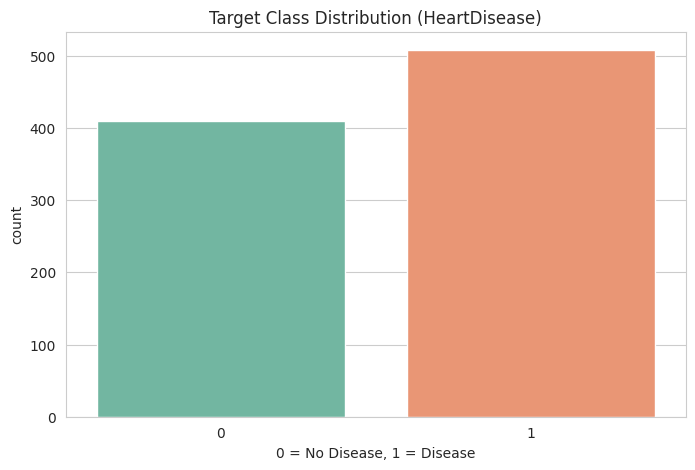

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [6]:
# Target distribution
plt.figure()
sns.countplot(x="HeartDisease", data=df, palette="Set2")
plt.title("Target Class Distribution (HeartDisease)")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.show()

df["HeartDisease"].value_counts(normalize=True) * 100


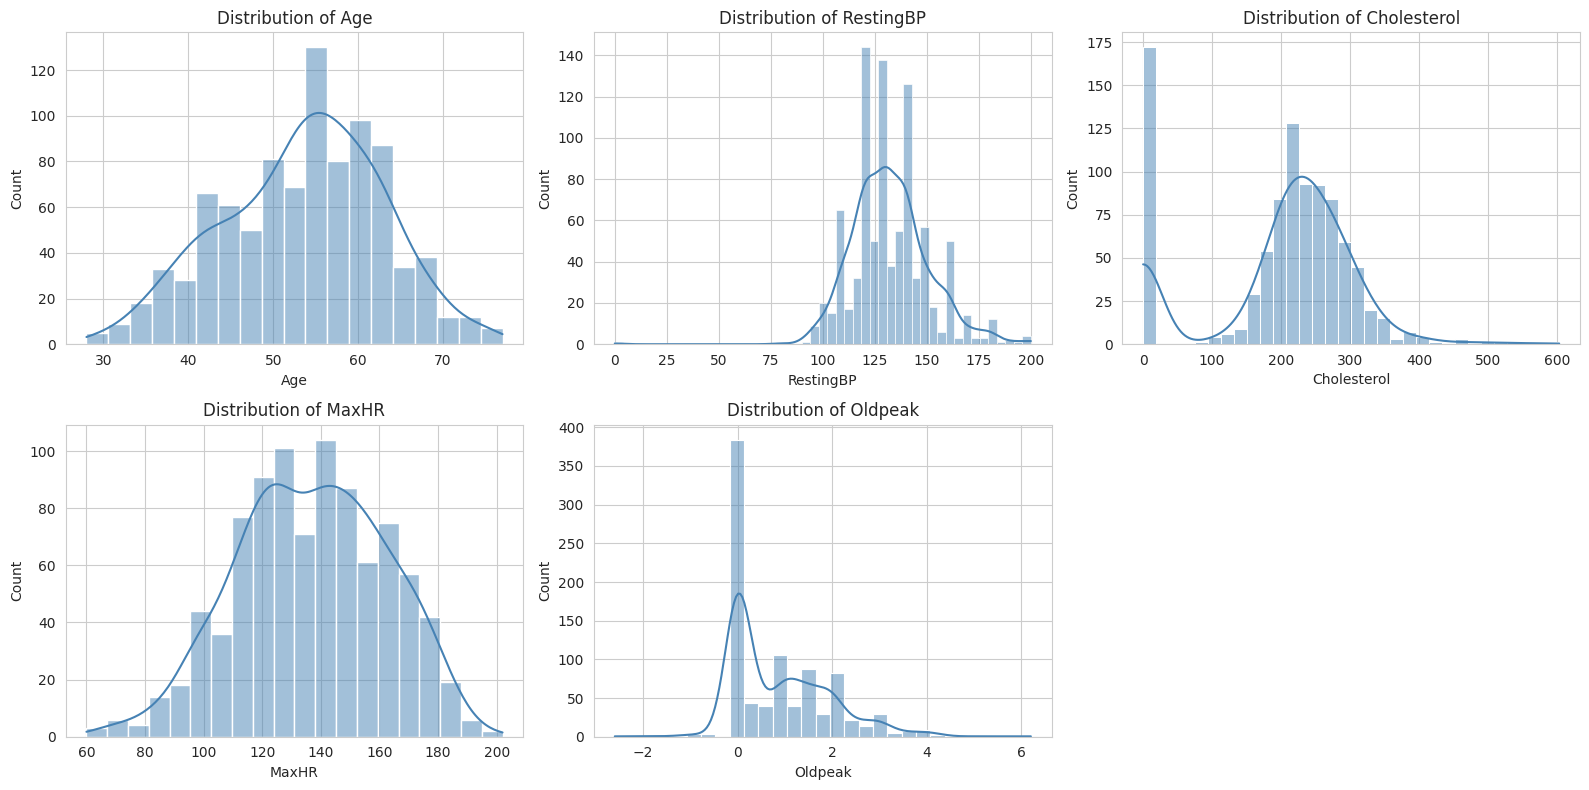

In [7]:
# Numerical feature distributions
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


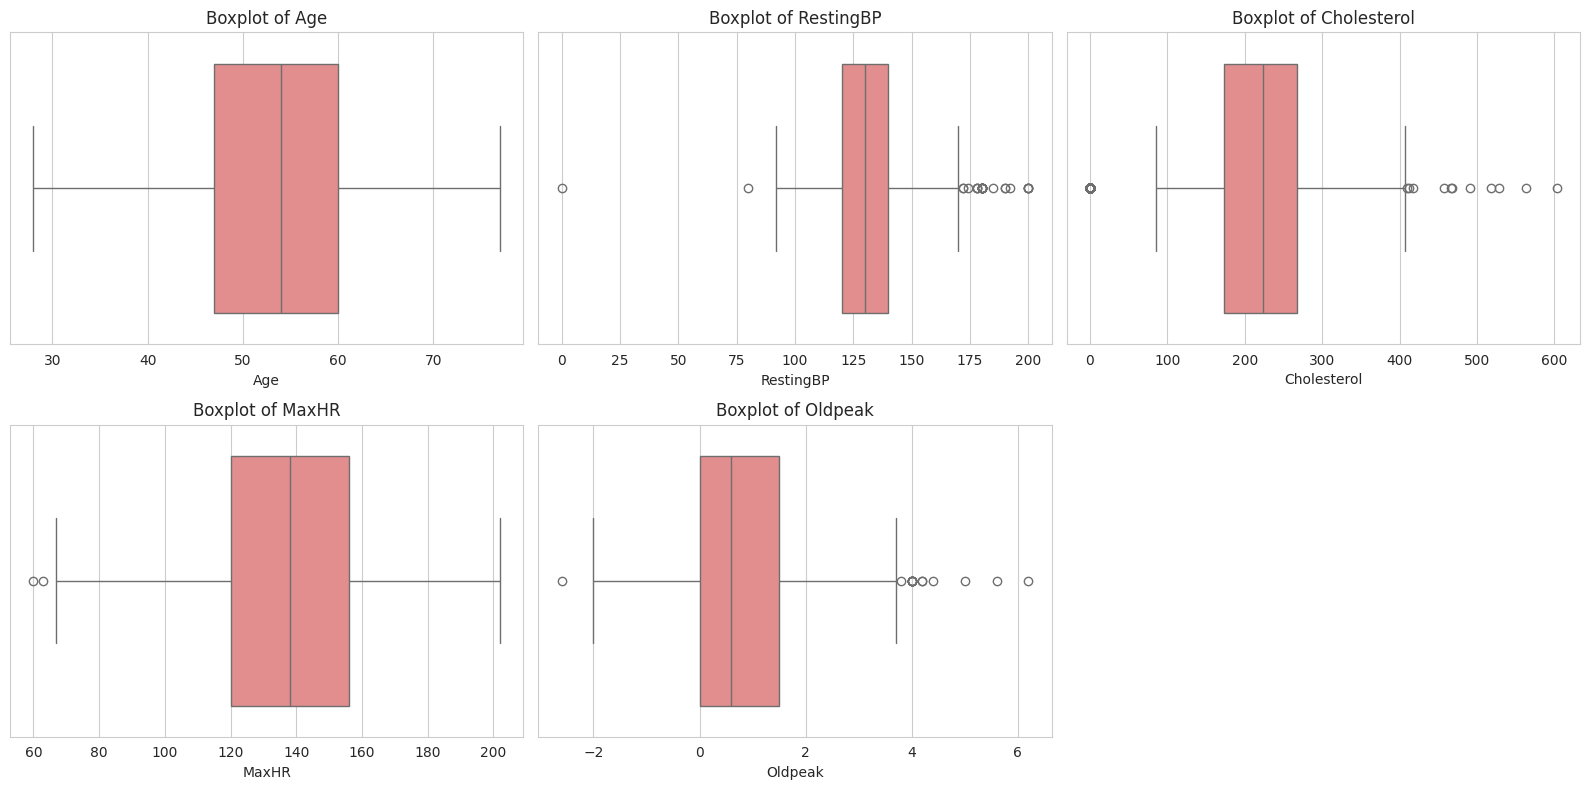

In [8]:
# Boxplots to spot outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


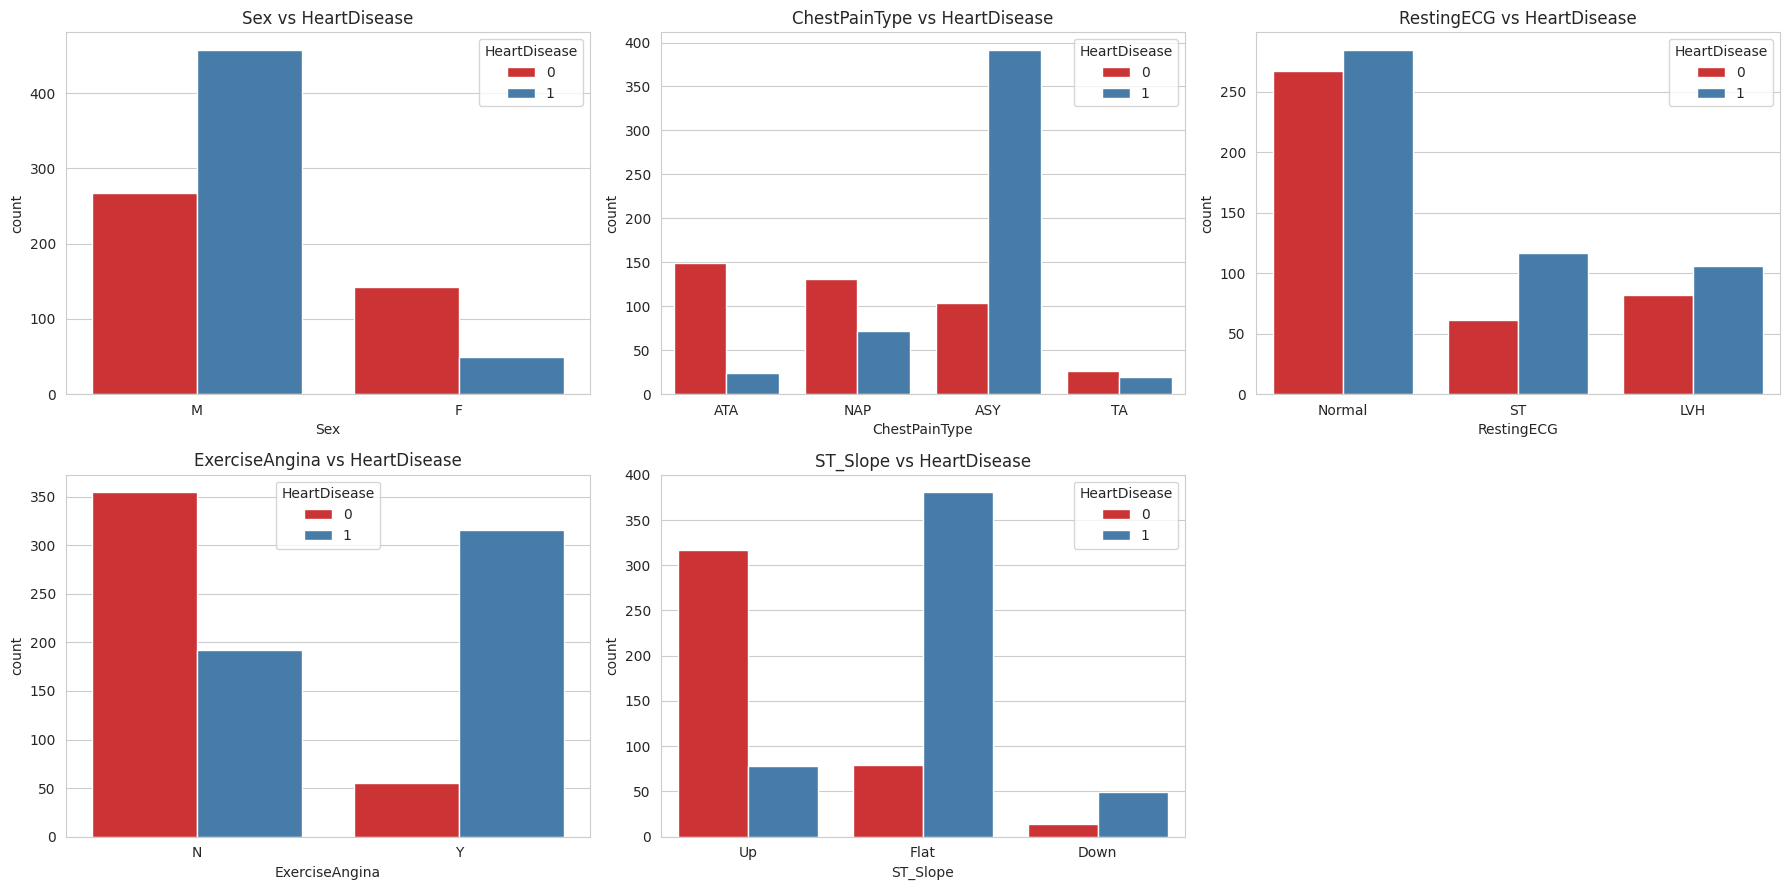

In [9]:
# Categorical features vs target
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue="HeartDisease", data=df, ax=axes[i], palette="Set1")
    axes[i].set_title(f"{col} vs HeartDisease")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


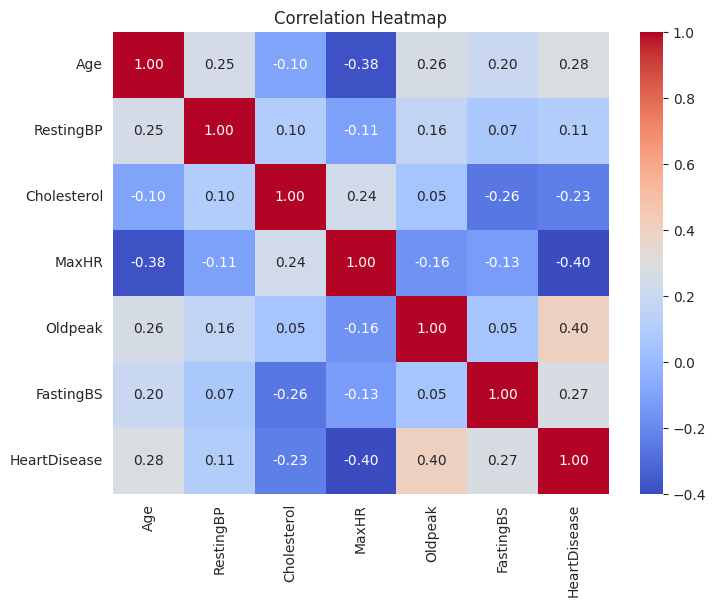

In [10]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(8, 6))
corr = df[num_cols + ["FastingBS", "HeartDisease"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 3. Data Cleaning

Physiologically, `Cholesterol` and `RestingBP` cannot be **0** — these are placeholder values for missing data,
not real measurements. We treat them as missing and impute with the **median** (grouped by target class where sensible)
rather than dropping ~19% of the rows.


In [11]:
print("Rows with Cholesterol == 0:", (df["Cholesterol"] == 0).sum())
print("Rows with RestingBP == 0   :", (df["RestingBP"] == 0).sum())

df_clean = df.copy()

# Replace 0s with NaN for the physiologically-impossible columns
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)

# Impute using the median of each target class (keeps signal by class)
for col in ["Cholesterol", "RestingBP"]:
    df_clean[col] = df_clean.groupby("HeartDisease")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("\nRemaining missing values:\n", df_clean.isnull().sum())


Rows with Cholesterol == 0: 172
Rows with RestingBP == 0   : 1

Remaining missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [12]:
# Encode categorical variables
label_encoders = {}
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le   # keep encoders so we can transform new sample inputs later

df_clean.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140.0,289.0,0,1,172,0,0.0,2,0
1,49,0,2,160.0,180.0,0,1,156,0,1.0,1,1
2,37,1,1,130.0,283.0,0,2,98,0,0.0,2,0
3,48,0,0,138.0,214.0,0,1,108,1,1.5,1,1
4,54,1,2,150.0,195.0,0,1,122,0,0.0,2,0


## 4. Train/Test Split & Feature Scaling

In [13]:
X = df_clean.drop("HeartDisease", axis=1)
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (734, 11)  Test shape: (184, 11)


## 5. Model Building

We train all 7 models on the same train/test split so results are directly comparable.

> **Note on Linear Regression:** Linear Regression is designed for continuous targets, not classification.
> Since the assignment calls for it alongside the classifiers, we fit it on the 0/1 target and convert its
> continuous output to a class by thresholding at 0.5. This is shown for comparison purposes — Logistic
> Regression is the statistically correct choice for this binary target.


In [14]:
results = {}
trained_models = {}

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    results[name] = acc
    print(f"===== {name} =====")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


===== Linear Regression =====
Accuracy: 0.8533
              precision    recall  f1-score   support

           0       0.84      0.83      0.83        82
           1       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



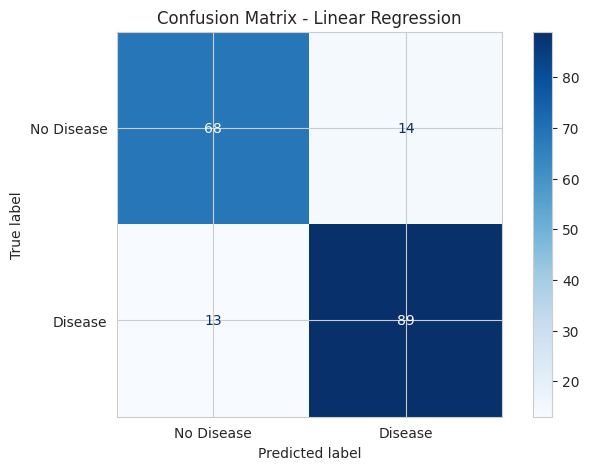

R2 score (regression view): 0.4727
RMSE (regression view): 0.3609


In [15]:
# 1) Linear Regression (thresholded at 0.5 for classification comparison)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_pred_raw = lin_reg.predict(X_test_scaled)
lin_pred = (lin_pred_raw >= 0.5).astype(int)

trained_models["Linear Regression"] = lin_reg
evaluate("Linear Regression", y_test, lin_pred)

print("R2 score (regression view):", round(r2_score(y_test, lin_pred_raw), 4))
print("RMSE (regression view):", round(np.sqrt(mean_squared_error(y_test, lin_pred_raw)), 4))


===== Logistic Regression =====
Accuracy: 0.8478
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



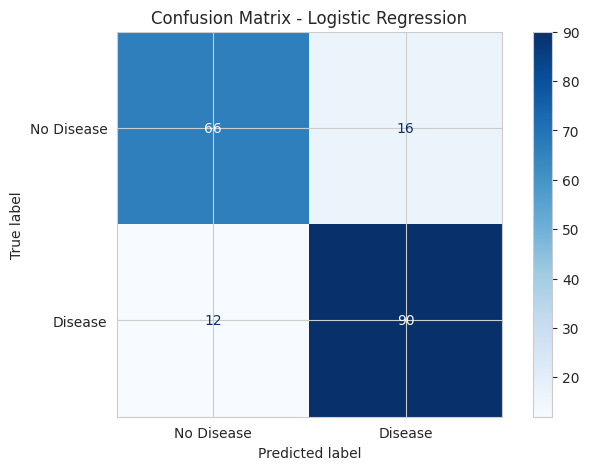

In [16]:
# 2) Logistic Regression
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)

trained_models["Logistic Regression"] = log_reg
evaluate("Logistic Regression", y_test, log_pred)


===== KNN =====
Accuracy: 0.8641
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



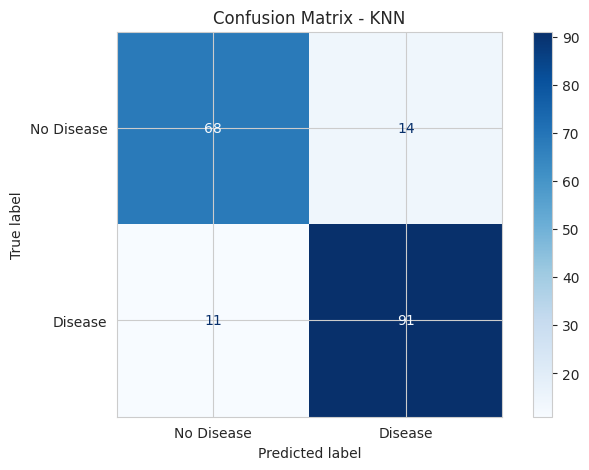

In [17]:
# 3) K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

trained_models["KNN"] = knn
evaluate("KNN", y_test, knn_pred)


===== Naive Bayes =====
Accuracy: 0.875
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



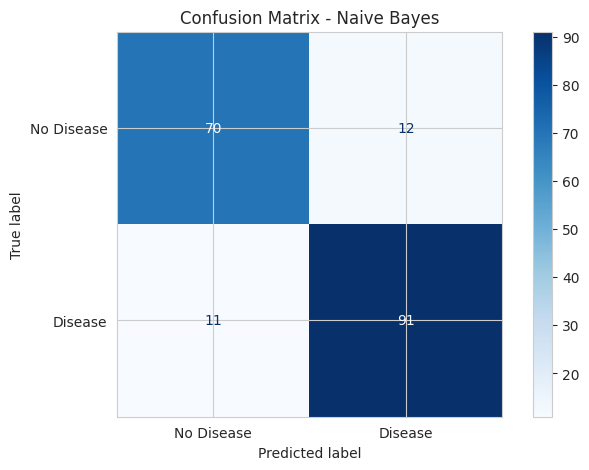

In [18]:
# 4) Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_test_scaled)

trained_models["Naive Bayes"] = nb
evaluate("Naive Bayes", y_test, nb_pred)


===== SVM =====
Accuracy: 0.8696
              precision    recall  f1-score   support

           0       0.89      0.80      0.85        82
           1       0.85      0.92      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



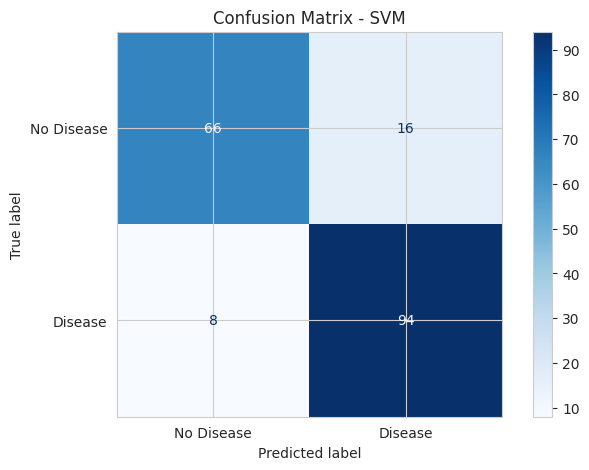

In [19]:
# 5) Support Vector Machine
svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

trained_models["SVM"] = svm
evaluate("SVM", y_test, svm_pred)


===== Decision Tree =====
Accuracy: 0.8478
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        82
           1       0.86      0.86      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



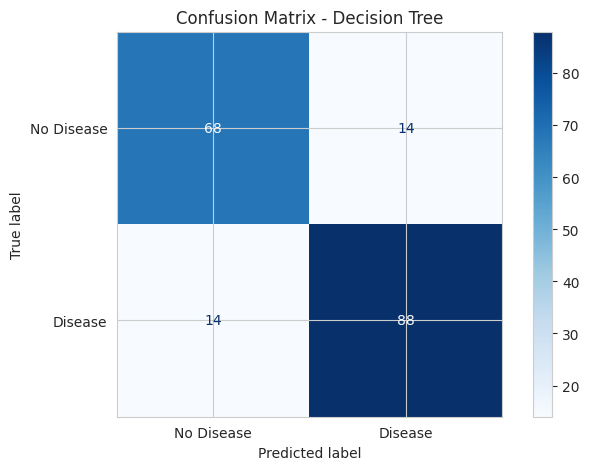

In [20]:
# 6) Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

trained_models["Decision Tree"] = dt
evaluate("Decision Tree", y_test, dt_pred)


===== Random Forest =====
Accuracy: 0.913
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        82
           1       0.91      0.93      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



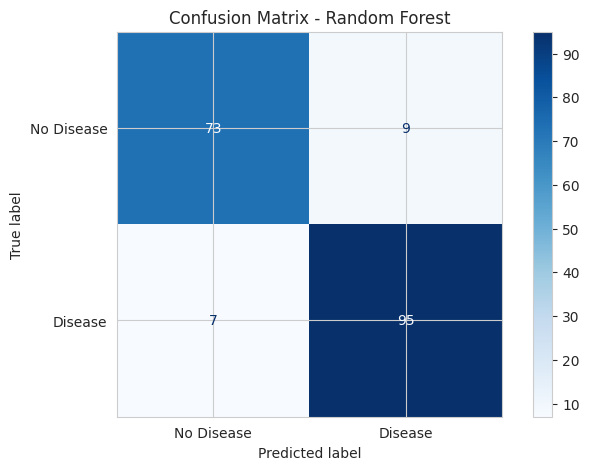

In [21]:
# 7) Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

trained_models["Random Forest"] = rf
evaluate("Random Forest", y_test, rf_pred)


## 6. Model Comparison

In [22]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy
0,Random Forest,0.913043
1,Naive Bayes,0.875000
2,SVM,0.869565
3,KNN,0.864130
4,Linear Regression,0.853261
5,Logistic Regression,0.847826
6,Decision Tree,0.847826


/tmp/ipykernel_598/259263831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


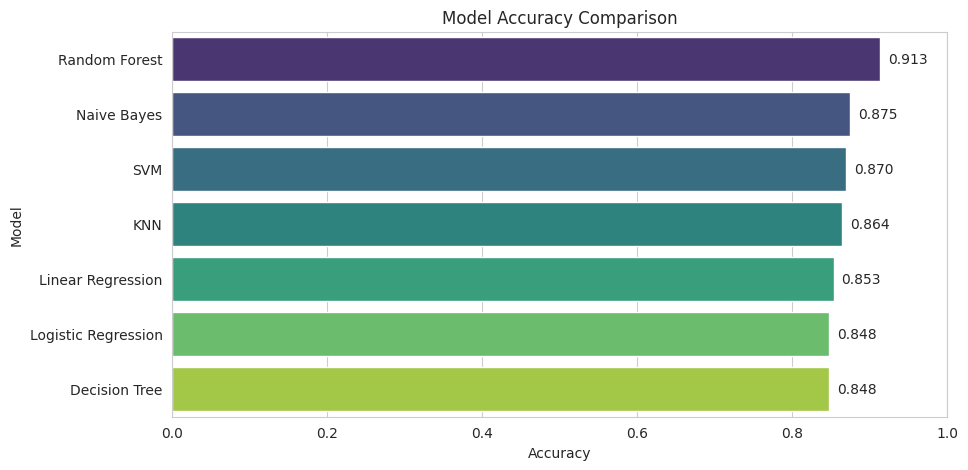

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.show()


## 7. Feature Importance (Random Forest)

/tmp/ipykernel_598/1215067936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


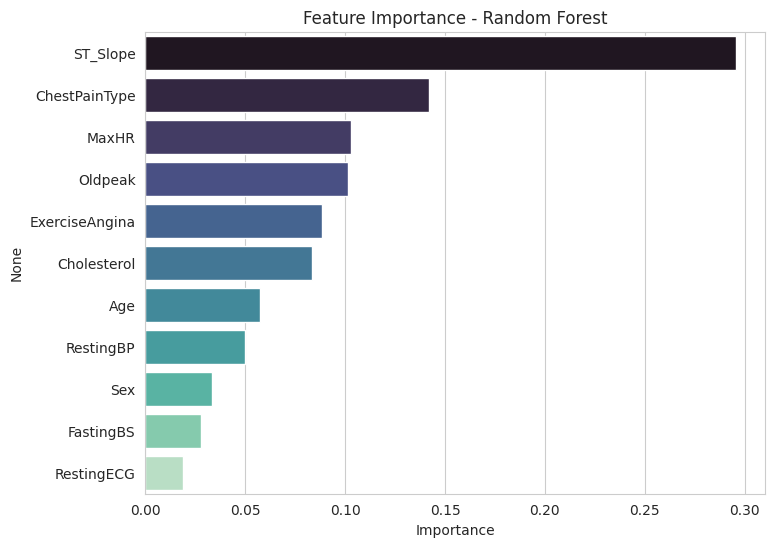

In [24]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()


## 8. Sample Prediction — Try a Single Patient

Below, a single hypothetical patient record is passed through the **same preprocessing pipeline**
(label encoding + scaling) used for training, then every model predicts on it so you can show
input → output for your demo.

Feel free to edit the values in `sample_input` to test different patients.


In [25]:
# --- Edit these values to test a different patient ---
sample_input = {
    "Age": 58,
    "Sex": "M",              # 'M' or 'F'
    "ChestPainType": "ASY",  # 'ATA', 'NAP', 'ASY', 'TA'
    "RestingBP": 145,
    "Cholesterol": 233,
    "FastingBS": 1,          # 1 if fasting blood sugar > 120 mg/dl, else 0
    "RestingECG": "ST",      # 'Normal', 'ST', 'LVH'
    "MaxHR": 120,
    "ExerciseAngina": "Y",   # 'Y' or 'N'
    "Oldpeak": 2.3,
    "ST_Slope": "Flat",      # 'Up', 'Flat', 'Down'
}

sample_df = pd.DataFrame([sample_input])

# Apply the same label encoders fitted during training
for col in categorical_cols:
    sample_df[col] = label_encoders[col].transform(sample_df[col])

# Reorder columns to match training feature order, then scale
sample_df = sample_df[X.columns]
sample_scaled = scaler.transform(sample_df)

print("Input patient record:")
sample_df_display = pd.DataFrame([sample_input])
sample_df_display


Input patient record:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,58,M,ASY,145,233,1,ST,120,Y,2.3,Flat


In [26]:
print("Prediction for this patient across all 7 models:\n")

label_map = {0: "No Heart Disease", 1: "Heart Disease Present"}

# Linear Regression (thresholded)
lin_out = lin_reg.predict(sample_scaled)[0]
print(f"Linear Regression   -> raw score: {lin_out:.3f}  =>  {label_map[int(lin_out >= 0.5)]}")

# Logistic Regression
log_out = log_reg.predict(sample_scaled)[0]
log_proba = log_reg.predict_proba(sample_scaled)[0][1]
print(f"Logistic Regression -> {label_map[log_out]}  (probability of disease: {log_proba:.3f})")

# KNN
knn_out = knn.predict(sample_scaled)[0]
print(f"KNN                  -> {label_map[knn_out]}")

# Naive Bayes
nb_out = nb.predict(sample_scaled)[0]
nb_proba = nb.predict_proba(sample_scaled)[0][1]
print(f"Naive Bayes          -> {label_map[nb_out]}  (probability of disease: {nb_proba:.3f})")

# SVM
svm_out = svm.predict(sample_scaled)[0]
svm_proba = svm.predict_proba(sample_scaled)[0][1]
print(f"SVM                  -> {label_map[svm_out]}  (probability of disease: {svm_proba:.3f})")

# Decision Tree
dt_out = dt.predict(sample_scaled)[0]
print(f"Decision Tree        -> {label_map[dt_out]}")

# Random Forest
rf_out = rf.predict(sample_scaled)[0]
rf_proba = rf.predict_proba(sample_scaled)[0][1]
print(f"Random Forest        -> {label_map[rf_out]}  (probability of disease: {rf_proba:.3f})")


Prediction for this patient across all 7 models:

Linear Regression   -> raw score: 1.053  =>  Heart Disease Present
Logistic Regression -> Heart Disease Present  (probability of disease: 0.982)
KNN                  -> Heart Disease Present
Naive Bayes          -> Heart Disease Present  (probability of disease: 1.000)
SVM                  -> Heart Disease Present  (probability of disease: 0.957)
Decision Tree        -> Heart Disease Present
Random Forest        -> Heart Disease Present  (probability of disease: 0.976)


## 9. Summary

| Step | What we did |
|---|---|
| EDA | Checked distributions, class balance, outliers, and correlations |
| Cleaning | Treated impossible 0-values in `Cholesterol`/`RestingBP` as missing, imputed by class median |
| Encoding | Label-encoded categorical columns, standardized numeric features |
| Modeling | Trained Linear Regression, Logistic Regression, KNN, Naive Bayes, SVM, Decision Tree, Random Forest |
| Evaluation | Accuracy, confusion matrix, classification report per model + a side-by-side comparison chart |
| Demo | A single editable patient record run through every trained model, with predicted label (and probability where available) |


